# Inflação de candidaturas 2018→2022: crescimento uniforme ou heterogêneo entre partidos?

O número de candidaturas a Deputado Federal cresce de forma acentuada entre 2018 e 2022.
Esse crescimento costuma ser lido junto da explosão do FEFC (+~144% nominal) — mais dinheiro
permite sustentar mais candidaturas simultaneamente (ver decomposição do NECr em
`3_necr.ipynb`, seção 13, e `cap3_necr_decomposicao.py`). Mas antes de discutir dinheiro, vale
isolar o fato bruto: quantas candidaturas a mais aparecem em 2022, e essa "inflação de
correligionários" — mais candidatos do mesmo partido disputando a mesma lista — é homogênea
entre partidos, ou concentrada nalguns?

Isso importa para a tese porque o NECr é sensível ao denominador da lista: se alguns partidos
inflam o tamanho da lista muito mais que outros, comparações de dispersão de recursos entre
partidos (ou entre 2018 e 2022) podem confundir "menos coordenação" com "lista simplesmente
maior". Este notebook é puramente descritivo — não estima efeito causal — e serve de
diagnóstico complementar às análises de `4_coordenacao_expansiva_2022.ipynb`.

Perguntas:
1. Qual a magnitude do crescimento nacional de candidaturas entre 2018 e 2022 (com 2014 como
   contraponto pré-FEFC / pré-fim das coligações proporcionais)?
2. Esse crescimento se distribui uniformemente entre as listas partido×UF, ou é concentrado?
3. A inflação é igual para todos os partidos, ou há heterogeneidade sistemática — por tamanho
   do partido, competitividade, ou participação em federação (o instituto criado em 2021 que
   permite a partidos combinarem atuação e, na prática, ampliar o espaço conjunto de
   candidaturas)?

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src" / "2_gold"))

from cap3_cs_features import gerar_features, carregar_rrd

pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 60)

HARMONIZACAO = {
    "PP**": "PP",
    "PCdoB": "PC do B",
    "PTdoB": "PT do B",
    "SD": "SOLIDARIEDADE",
    "DEM": "UNIÃO",
    "PR": "PL",
    "PRB": "REPUBLICANOS",
}

rrd = gerar_features(carregar_rrd())
rrd["sg_partido"] = rrd["sg_partido"].replace(HARMONIZACAO)
print(f"rrd (2014+2018+2022): {len(rrd):,} candidaturas a Deputado Federal")
print(rrd["ano_eleicao"].value_counts().sort_index().to_string())

rrd (2014+2018+2022): 23,483 candidaturas a Deputado Federal
ano_eleicao
2014    6178
2018    7630
2022    9675


Mesma harmonização de sigla partidária usada no resto do projeto (`DEM→UNIÃO`, `PR→PL`,
`PRB→REPUBLICANOS`, etc. — ver CLAUDE.md). Fusões não cobertas por essa tabela canônica
(p.ex. `PSL→UNIÃO`, `PPS→CIDADANIA`, `PATRI→PATRIOTA`) permanecem como entidades distintas
entre 2018 e 2022 — isso é uma limitação real da comparação por sigla e é tratado
explicitamente na Seção 3 (partidos sem par em ambos os anos são descartados do cálculo de
crescimento, não imputados).

## 1. Magnitude nacional do crescimento

In [2]:
n_candidaturas = rrd.groupby("ano_eleicao").size().rename("n_candidaturas")
n_listas = (
    rrd.drop_duplicates(["ano_eleicao", "sg_uf", "sg_partido"])
    .groupby("ano_eleicao").size().rename("n_listas")
)
n_vagas = (
    rrd.drop_duplicates(["ano_eleicao", "sg_uf"])
    .groupby("ano_eleicao")["qt_vaga"].sum().rename("n_vagas")
)

nacional = pd.concat([n_candidaturas, n_listas, n_vagas], axis=1)
nacional["candidatos_por_vaga"] = nacional["n_candidaturas"] / nacional["n_vagas"]
nacional["candidatos_por_lista"] = nacional["n_candidaturas"] / nacional["n_listas"]
nacional["crescimento_candidaturas_pct"] = nacional["n_candidaturas"].pct_change() * 100

print(nacional.round(2).to_string())

             n_candidaturas  n_listas  n_vagas  candidatos_por_vaga  candidatos_por_lista  crescimento_candidaturas_pct
ano_eleicao                                                                                                            
2014                   6178       776      513                12.04                  7.96                           NaN
2018                   7630       859      513                14.87                  8.88                          23.5
2022                   9675       711      513                18.86                 13.61                          26.8


## 2. Crescimento por lista (partido × UF): distribuição

In [3]:
listas = (
    rrd.groupby(["ano_eleicao", "sg_uf", "sg_partido"])
    .agg(n_cands=("nr_candidato", "size"), qt_vaga=("qt_vaga", "first"))
    .reset_index()
)
listas["cands_por_vaga"] = listas["n_cands"] / listas["qt_vaga"]

piv = listas[listas.ano_eleicao.isin([2018, 2022])].pivot_table(
    index=["sg_uf", "sg_partido"], columns="ano_eleicao", values="n_cands"
)
piv.columns = ["n_cands_2018", "n_cands_2022"]

pareadas = piv.dropna().copy()
pareadas["delta"] = pareadas["n_cands_2022"] - pareadas["n_cands_2018"]
pareadas["cresc_pct"] = pareadas["delta"] / pareadas["n_cands_2018"] * 100

print(f"Combinações partido×UF: {len(piv):,}")
print(f"Presentes em 2018 e 2022 (pareadas): {len(pareadas):,}")
print(f"Só em 2018 (saída de cena): {int(piv['n_cands_2022'].isna().sum())}")
print(f"Só em 2022 (entrada): {int(piv['n_cands_2018'].isna().sum())}")
print()
print(pareadas[["n_cands_2018", "n_cands_2022", "delta", "cresc_pct"]].describe().round(2).to_string())

Combinações partido×UF: 976
Presentes em 2018 e 2022 (pareadas): 594
Só em 2018 (saída de cena): 265
Só em 2022 (entrada): 117

       n_cands_2018  n_cands_2022   delta  cresc_pct
count        594.00        594.00  594.00     594.00
mean           9.19         14.49    5.30     249.39
std           13.73         14.15   11.68     405.67
min            1.00          1.00  -69.00     -95.00
25%            2.00          6.00    0.00       0.00
50%            4.00          9.00    5.00     100.00
75%            9.00         18.00    9.00     350.00
max           97.00         71.00   59.00    3000.00


In [4]:
stat, p = stats.wilcoxon(pareadas["n_cands_2018"], pareadas["n_cands_2022"])
print(f"Wilcoxon (pareado) n_cands 2018 vs 2022: estatística={stat:.1f}, p={p:.2e}")

piv_vaga = listas[listas.ano_eleicao.isin([2018, 2022])].pivot_table(
    index=["sg_uf", "sg_partido"], columns="ano_eleicao", values="cands_por_vaga"
).dropna()
piv_vaga.columns = ["cpv_2018", "cpv_2022"]

stat2, p2 = stats.wilcoxon(piv_vaga["cpv_2018"], piv_vaga["cpv_2022"])
print(f"Candidatos por vaga — média 2018: {piv_vaga['cpv_2018'].mean():.2f}, "
      f"2022: {piv_vaga['cpv_2022'].mean():.2f}")
print(f"Wilcoxon (pareado) candidatos/vaga 2018 vs 2022: p={p2:.2e}")

Wilcoxon (pareado) n_cands 2018 vs 2022: estatística=32410.0, p=2.66e-34
Candidatos por vaga — média 2018: 0.43, 2022: 0.74
Wilcoxon (pareado) candidatos/vaga 2018 vs 2022: p=8.25e-42


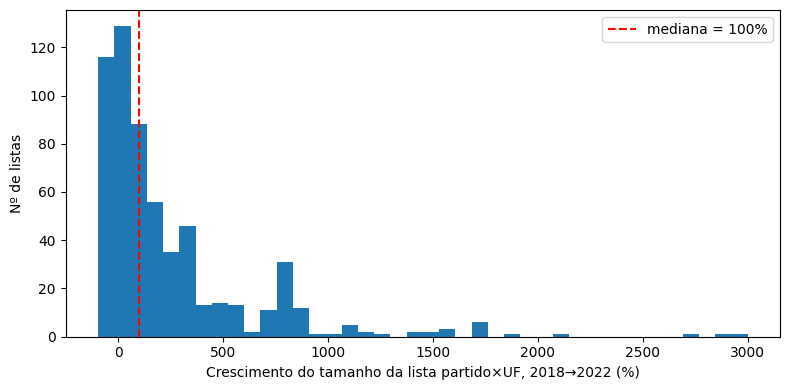

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pareadas["cresc_pct"], bins=40)
ax.axvline(
    pareadas["cresc_pct"].median(), color="red", linestyle="--",
    label=f"mediana = {pareadas['cresc_pct'].median():.0f}%",
)
ax.set_xlabel("Crescimento do tamanho da lista partido×UF, 2018→2022 (%)")
ax.set_ylabel("Nº de listas")
ax.legend()
plt.tight_layout()
plt.show()

A dispersão em torno da mediana já sugere que o crescimento não é um deslocamento uniforme
de todas as listas — há listas que dobram ou triplicam de tamanho e outras que encolhem. A
seção seguinte agrega isso por partido (nacionalmente, somando UFs) para checar se esse
padrão é sistemático entre partidos ou apenas ruído entre listas estaduais do mesmo
partido.

## 3. Heterogeneidade entre partidos

In [6]:
partido_ano = (
    rrd[rrd.ano_eleicao.isin([2018, 2022])]
    .groupby(["sg_partido", "ano_eleicao"])
    .size()
    .unstack("ano_eleicao")
)
partido_ano.columns = ["n_2018", "n_2022"]

partido_cresc = partido_ano.dropna().copy()
partido_cresc["delta"] = partido_cresc["n_2022"] - partido_cresc["n_2018"]
partido_cresc["cresc_pct"] = partido_cresc["delta"] / partido_cresc["n_2018"] * 100
partido_cresc = partido_cresc.sort_values("cresc_pct", ascending=False)

print(f"Partidos presentes em ambas as eleições (sigla harmonizada): {len(partido_cresc)} "
      f"de {len(partido_ano)}")
print(partido_cresc.round(1).to_string())

Partidos presentes em ambas as eleições (sigla harmonizada): 28 de 39
               n_2018  n_2022  delta  cresc_pct
sg_partido                                     
PCO               5.0    30.0   25.0      500.0
PTB             129.0   472.0  343.0      265.9
PP              139.0   481.0  342.0      246.0
PL              152.0   485.0  333.0      219.1
UNIÃO           168.0   495.0  327.0      194.6
SOLIDARIEDADE   145.0   373.0  228.0      157.2
PSC             173.0   404.0  231.0      133.5
PODE            213.0   481.0  268.0      125.8
PSD             195.0   403.0  208.0      106.7
REPUBLICANOS    248.0   509.0  261.0      105.2
PMB              96.0   184.0   88.0       91.7
PSB             226.0   426.0  200.0       88.5
PDT             269.0   456.0  187.0       69.5
PMN             164.0   266.0  102.0       62.2
MDB             304.0   467.0  163.0       53.6
PROS            268.0   340.0   72.0       26.9
PSDB            237.0   293.0   56.0       23.6
AVANTE          33

In [7]:
media = partido_cresc["cresc_pct"].mean()
dp = partido_cresc["cresc_pct"].std()
cv = dp / media

print(f"Crescimento médio entre partidos: {media:.1f}% (DP={dp:.1f} p.p., CV={cv:.2f})")
print(f"Amplitude: {partido_cresc['cresc_pct'].min():.1f}% a {partido_cresc['cresc_pct'].max():.1f}%")
print(f"Partidos com crescimento negativo: {(partido_cresc['cresc_pct'] < 0).sum()} "
      f"de {len(partido_cresc)}")

Crescimento médio entre partidos: 83.3% (DP=120.6 p.p., CV=1.45)
Amplitude: -66.5% a 500.0%
Partidos com crescimento negativo: 6 de 28


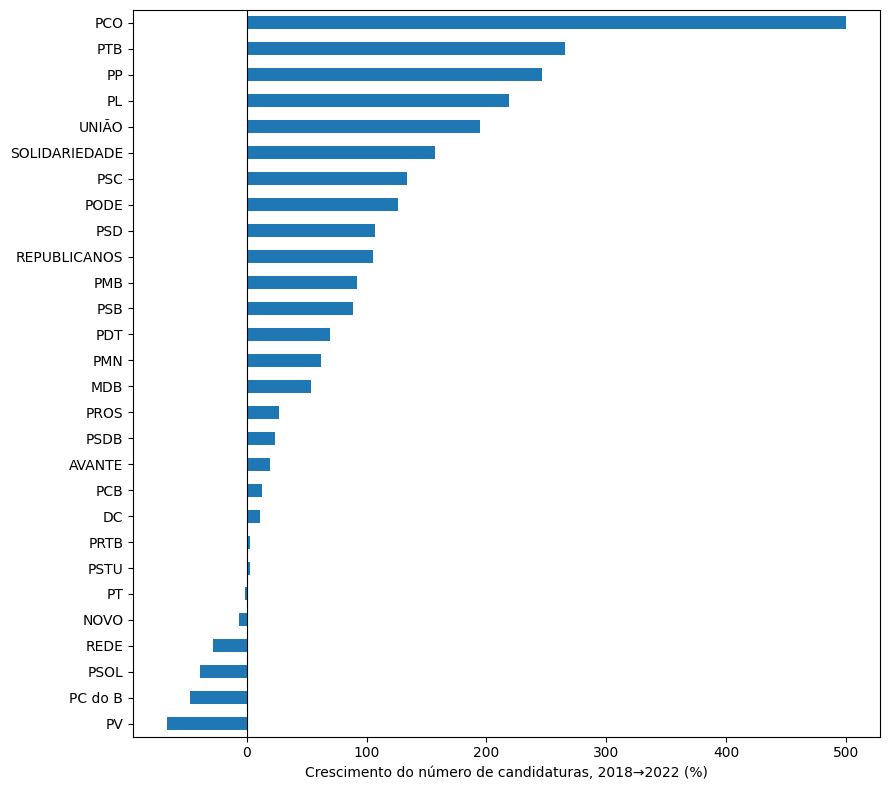

In [8]:
fig, ax = plt.subplots(figsize=(9, 8))
partido_cresc["cresc_pct"].sort_values().plot.barh(ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Crescimento do número de candidaturas, 2018→2022 (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. Correlatos do crescimento: tamanho do partido e competitividade

In [9]:
tamanho_2018 = (
    rrd[rrd.ano_eleicao == 2018]
    .drop_duplicates("sg_partido")
    .set_index("sg_partido")["cadeiras_nacionais"]
)
partido_cresc = partido_cresc.join(tamanho_2018.rename("cadeiras_2018"))
partido_cresc["tipo_partido_2018"] = np.where(
    partido_cresc["cadeiras_2018"] >= 20, "Competitivo", "Menos competitivo"
)

rho, p_rho = stats.spearmanr(partido_cresc["cadeiras_2018"], partido_cresc["cresc_pct"])
print(f"Correlação de Spearman entre crescimento % e cadeiras nacionais em 2018: "
      f"rho={rho:.2f}, p={p_rho:.3f}")
print()
print(
    partido_cresc.groupby("tipo_partido_2018")["cresc_pct"]
    .agg(["mean", "median", "std", "count"]).round(1).to_string()
)

Correlação de Spearman entre crescimento % e cadeiras nacionais em 2018: rho=0.31, p=0.114

                    mean  median    std  count
tipo_partido_2018                             
Competitivo        110.6    96.9   83.5     10
Menos competitivo   68.1    16.3  136.8     18


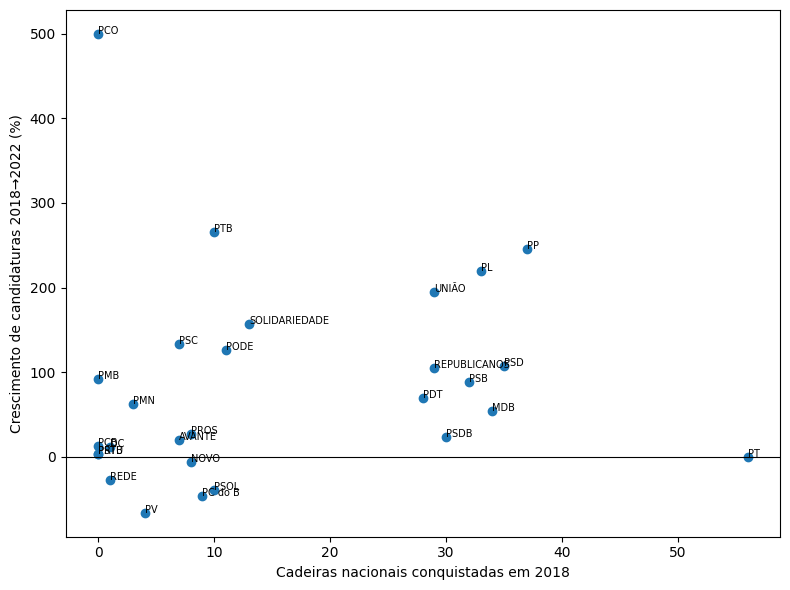

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(partido_cresc["cadeiras_2018"], partido_cresc["cresc_pct"])
for partido, row in partido_cresc.iterrows():
    ax.annotate(partido, (row["cadeiras_2018"], row["cresc_pct"]), fontsize=7)
ax.set_xlabel("Cadeiras nacionais conquistadas em 2018")
ax.set_ylabel("Crescimento de candidaturas 2018→2022 (%)")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Federações (2022): um candidato institucional para a heterogeneidade?

O fim das coligações proporcionais elimina, a partir de 2020, a possibilidade de partidos
somarem listas de candidatos para fins eleitorais. As federações partidárias (Lei
14.208/2021), no entanto, permitem que dois ou mais partidos se apresentem sob atuação
parlamentar conjunta por pelo menos 4 anos e, perante a Justiça Eleitoral, sejam tratados como
uma única entidade partidária. Isso é um candidato institucional natural para explicar
heterogeneidade: partidos que entraram em federação em 2022 cresceram mais do que os que
concorreram isoladamente? (O texto legal exato do teto de candidaturas por federação não é
verificado aqui — a análise é puramente correlacional, a partir da composição registrada no
TSE.)

In [11]:
resultados = pd.read_parquet(ROOT / "data" / "processed" / "resultados.parquet")

res22 = resultados.loc[
    (resultados.ano_eleicao == 2022)
    & (resultados.ds_cargo.str.upper() == "DEPUTADO FEDERAL")
    & (resultados.nr_turno == 1),
    ["sg_uf", "sg_partido", "nr_candidato", "ds_composicao_coligacao"],
].drop_duplicates(["sg_uf", "nr_candidato"]).copy()
res22["sg_partido"] = res22["sg_partido"].replace(HARMONIZACAO)
res22["em_federacao"] = res22["ds_composicao_coligacao"].str.contains("Federa", case=False, na=False)

fed_flag_uf = res22.groupby("sg_partido")["em_federacao"].mean()
inconsistentes = fed_flag_uf[(fed_flag_uf > 0) & (fed_flag_uf < 1)]
print("Partidos com status de federação inconsistente entre UFs (deveria ser raro/vazio):")
print(inconsistentes.round(2).to_string() if len(inconsistentes) else "  (nenhum)")

fed_flag = fed_flag_uf >= 0.5
print()
print(f"Partidos federados em 2022: {sorted(fed_flag[fed_flag].index.tolist())}")

Partidos com status de federação inconsistente entre UFs (deveria ser raro/vazio):
  (nenhum)

Partidos federados em 2022: ['CIDADANIA', 'PC do B', 'PSDB', 'PSOL', 'PT', 'PV', 'REDE']


In [12]:
partido_cresc["federacao_2022"] = partido_cresc.index.map(fed_flag).fillna(False)

print(
    partido_cresc.groupby("federacao_2022")["cresc_pct"]
    .agg(["mean", "median", "std", "count"]).round(1).to_string()
)
print()

grupo_fed = partido_cresc.loc[partido_cresc.federacao_2022, "cresc_pct"]
grupo_nao_fed = partido_cresc.loc[~partido_cresc.federacao_2022, "cresc_pct"]
u, p_u = stats.mannwhitneyu(grupo_fed, grupo_nao_fed)
print(f"Mann-Whitney U (federados vs. não-federados): U={u:.1f}, p={p_u:.3f}")

                 mean  median    std  count
federacao_2022                             
False           113.2    90.1  118.6     22
True            -26.4   -33.6   32.7      6

Mann-Whitney U (federados vs. não-federados): U=7.0, p=0.000


## 6. Listas conjuntas de federação: o tamanho combinado se aproxima do padrão das antigas coligações?

Em vez de olhar cada partido federado isoladamente, soma-se o tamanho das listas dos partidos
que integram a mesma federação, na mesma UF, e compara-se `candidatos/vaga` desse bloco
combinado com o de listas de partidos que concorreram sozinhos em 2022.

In [13]:
res22["federacao_nome"] = res22["ds_composicao_coligacao"].where(res22["em_federacao"])
res22["federacao_nome"] = res22["federacao_nome"].str.extract(r"^(.*?)\(")[0].str.strip()

fed_listas = (
    res22[res22.em_federacao]
    .groupby(["sg_uf", "federacao_nome"])
    .size()
    .rename("n_cands_federacao")
    .reset_index()
)

vagas_uf = (
    rrd.loc[rrd.ano_eleicao == 2022]
    .drop_duplicates("sg_uf")
    .set_index("sg_uf")["qt_vaga"]
)
fed_listas["qt_vaga"] = fed_listas["sg_uf"].map(vagas_uf)
fed_listas["cands_por_vaga"] = fed_listas["n_cands_federacao"] / fed_listas["qt_vaga"]

listas_2022 = listas[listas.ano_eleicao == 2022]
partidos_federados = fed_flag[fed_flag].index
nao_federadas = listas_2022[~listas_2022["sg_partido"].isin(partidos_federados)]

print("Candidatos/vaga — listas de partido isolado (não-federado), 2022:")
print(nao_federadas["cands_por_vaga"].describe().round(2).to_string())
print()
print("Candidatos/vaga — listas combinadas de federação, 2022:")
print(fed_listas["cands_por_vaga"].describe().round(2).to_string())
print()

u2, p2_u = stats.mannwhitneyu(fed_listas["cands_por_vaga"], nao_federadas["cands_por_vaga"])
print(f"Mann-Whitney U (bloco de federação vs. lista de partido isolado): U={u2:.1f}, p={p2_u:.3f}")

Candidatos/vaga — listas de partido isolado (não-federado), 2022:
count    533.00
mean       0.79
std        0.34
min        0.01
25%        0.62
50%        0.90
75%        1.06
max        1.12

Candidatos/vaga — listas combinadas de federação, 2022:
count    80.00
mean      0.97
std       0.16
min       0.42
25%       0.88
50%       1.00
75%       1.10
max       1.12

Mann-Whitney U (bloco de federação vs. lista de partido isolado): U=27189.5, p=0.000


## Síntese

**1. Magnitude nacional.** O número de vagas é fixo (513) nas três eleições, mas as
candidaturas saltam de 6.178 (2014) para 7.630 (2018, +23,5%) e 9.675 (2022, +26,8%) — o
crescimento 2018→2022 é, em termos relativos, ainda maior que o salto anterior. `Candidatos
por vaga` sobe de 12,0 → 14,9 → 18,9. Note-se que o número de *listas* partido×UF cai de 859
(2018) para 711 (2022) — reflexo, sobretudo, das fusões partidárias (PSL/DEM→UNIÃO,
PPS→CIDADANIA) que reduzem o número de siglas distintas — enquanto `candidatos por lista`
salta de 8,9 para 13,6. Ou seja: menos listas, mas bem maiores.

**2. Distribuição por lista.** Nas 594 listas partido×UF presentes em ambas as eleições, o
crescimento mediano é de +100% (média +249%, fortemente puxada por caudas — algumas listas
saem de 1 candidato para dezenas). O teste de Wilcoxon pareado confirma que o aumento é
sistemático, não ruído (p≈2,7e-34 para `n_cands`; p≈8,3e-42 para `candidatos/vaga`, que sobe
de 0,43 para 0,74 em média). A distribuição do crescimento percentual (histograma da Seção 2)
é assimétrica à direita, com metade das listas crescendo entre 0% e 350%.

**3. Heterogeneidade entre partidos — resposta à pergunta central: não, a inflação não é
igual para todos os partidos.** Entre os 28 partidos com sigla comparável nas duas eleições,
o crescimento varia de **−66,5% (PV)** a **+500% (PCO)**, com média de 83,3% e um coeficiente
de variação de 1,45 — dispersão enorme frente à média. Seis partidos (PT, NOVO, REDE, PSOL,
PC do B, PV) efetivamente **reduziram** o número de candidaturas, todos eles fora do grupo de
partidos "menores"; os seis são exatamente os que, em 2022, integraram uma federação.

**4. Tamanho e competitividade explicam pouco.** A correlação entre cadeiras conquistadas em
2018 e crescimento % não é significativa (Spearman ρ=0,31, p=0,114). Partidos "competitivos"
(≥20 cadeiras nacionais) crescem um pouco mais em média (110,6% vs. 68,1%), mas a dispersão
entre os "menos competitivos" é maior (DP=136,8 vs. 83,5) — não há um padrão limpo de que
partidos maiores ou mais competitivos infladem mais suas listas.

**5. Federação é o fator que separa os grupos com nitidez.** Os 7 partidos que entraram em
federação em 2022 (CIDADANIA, PC do B, PSDB, PSOL, PT, PV, REDE) tiveram crescimento médio de
**−26,4%** (mediana −33,6%) em candidaturas *próprias*, contra **+113,2%** (mediana +90,1%)
dos partidos que concorreram isoladamente — diferença altamente significativa (Mann-Whitney
p<0,001). À primeira vista isso contraria a hipótese de que federações ampliam o espaço de
candidaturas de seus membros.

**6. Mas a explicação está no nível do bloco, não do partido.** Quando se soma o tamanho das
listas dos partidos de uma mesma federação, na mesma UF, a razão `candidatos/vaga` do bloco
combinado (mediana 1,00; média 0,97) é sistematicamente maior que a de listas de partidos que
concorreram sozinhos (mediana 0,90; média 0,79; Mann-Whitney p<0,001), e a mediana do bloco
está muito perto de 1,0 — praticamente saturando o teto de um candidato por vaga. O quadro
que emerge é: **federações concentram a expansão da lista no nível do bloco conjunto (perto
do teto legal), enquanto cada partido-membro, isoladamente, reduz sua própria contagem de
candidatos** — o oposto do padrão dos partidos não-federados, que inflaram suas listas
individualmente sem essa restrição de partilha. Isso é consistente com federações funcionando
como sucedâneo parcial das antigas coligações proporcionais para fins de ocupação de lista,
mas redistribuindo — não somando — o espaço de candidaturas entre os partidos-membros.

**Implicação para o NECr.** Como o crescimento de lista é tão heterogêneo — e associado a um
fator institucional específico (federação) que não afeta todos os partidos —, comparações de
NECr entre partidos em 2022, ou de um mesmo partido entre 2018 e 2022, devem controlar para
essa mudança de denominador (`n_cands` ou `candidatos/vaga`) antes de interpretar variações
de dispersão de recursos como mudança na coordenação intrapartidária. Isso reforça a
relevância da decomposição já feita em `3_necr.ipynb` (seção 13) e sugere que a classificação
de vulnerabilidade usada em `4_coordenacao_expansiva_2022.ipynb` poderia ser cruzada
diretamente com o status de federação como covariada adicional.